In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk


In [2]:
# Load the dataset
bank_df = pd.read_csv(r"C:\Users\msjoh\OneDrive\Documents\Project Luna\Churn_Modelling.csv")
bank_df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# Summary Statistics
bank_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Number of Rows and columns
bank_df.shape

(10000, 14)

In [6]:
# Data types for each column
bank_df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
# First 5 rows
bank_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Last 5 rows
bank_df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [9]:
# Check for missing values
bank_df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
bank_df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [11]:
# Change the column name
bank_df.rename(columns={"Geography":"Country"}, inplace=True)
bank_df

,RowNumber,CustomerId,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [12]:
# Remove the unwanted columns
bank_df.drop(["RowNumber","CustomerId"], axis=1, inplace=True)

bank_df.shape

(10000, 12)

In [13]:
# Summary statistics by gender
summary_by_gender = bank_df.groupby("Gender",as_index=False, observed=True).agg(Number_of_observations=("Gender","count"),
                                                                 Average_of_tenure=("Tenure","mean"),
                                                                 Mean_of_credit_score=("CreditScore","mean"))
summary_by_gender.round()

,Gender,Number_of_observations,Average_of_tenure,Mean_of_credit_score
0,Female,4543,5.0,651.0
1,Male,5457,5.0,650.0


In [14]:
# Convert to factor(category)
factor_cols = ["Country","Gender","NumOfProducts","HasCrCard","IsActiveMember","Exited"]
bank_df[factor_cols] = bank_df[factor_cols].astype("category")
bank_df.dtypes

Surname              object
CreditScore           int64
Country            category
Gender             category
Age                   int64
Tenure                int64
Balance             float64
NumOfProducts      category
HasCrCard          category
IsActiveMember     category
EstimatedSalary     float64
Exited             category
dtype: object

In [15]:
# 0 1 -> No Yes
cat_cols = ["HasCrCard","IsActiveMember","Exited"]
for col in cat_cols:
    bank_df[col] = bank_df[col].cat.rename_categories({0:"No",1:"Yes"})

In [16]:
bank_df

,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Hargrave,619,France,Female,42,2,0.00,1,Yes,Yes,101348.88,Yes
1,Hill,608,Spain,Female,41,1,83807.86,1,No,Yes,112542.58,No
2,Onio,502,France,Female,42,8,159660.80,3,Yes,No,113931.57,Yes
3,Boni,699,France,Female,39,1,0.00,2,No,No,93826.63,No
4,Mitchell,850,Spain,Female,43,2,125510.82,1,Yes,Yes,79084.10,No
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Obijiaku,771,France,Male,39,5,0.00,2,Yes,No,96270.64,No
9996,Johnstone,516,France,Male,35,10,57369.61,1,Yes,Yes,101699.77,No
9997,Liu,709,France,Female,36,7,0.00,1,No,Yes,42085.58,Yes
9998,Sabbatini,772,Germany,Male,42,3,75075.31,2,Yes,No,92888.52,Yes


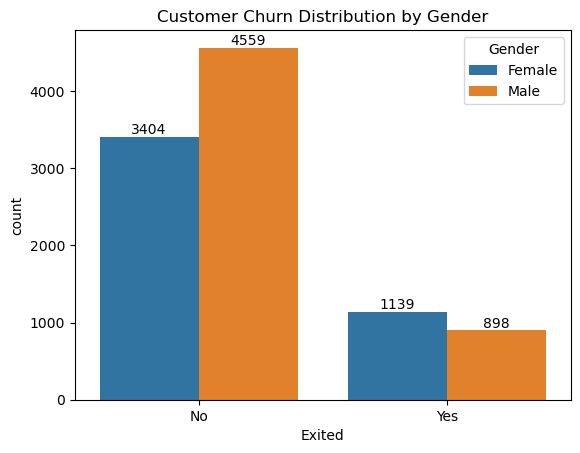

In [17]:
bar = sns.countplot(x='Exited', hue="Gender", data=bank_df)
plt.title("Customer Churn Distribution by Gender")
for container in bar.containers:
    bar.bar_label(container)
plt.show()

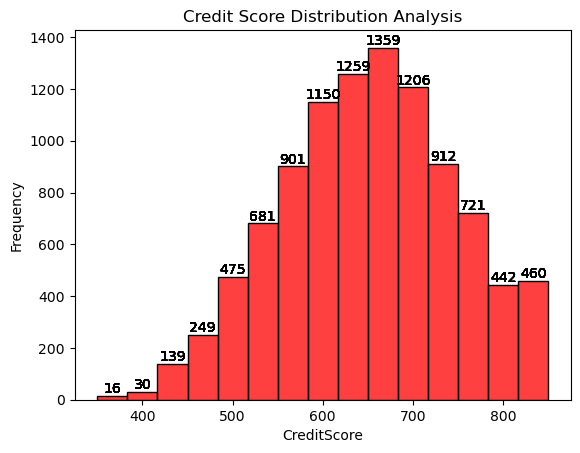

In [18]:
hist = sns.histplot(bank_df['CreditScore'], bins=15, color="red")
plt.title("Credit Score Distribution Analysis")
for container in hist.containers[0]:
    hist.bar_label(hist.containers[0])
plt.ylabel("Frequency")
plt.show()

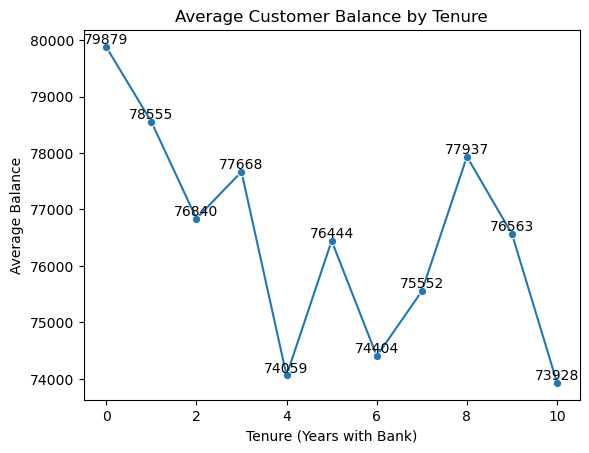

In [29]:
tenure_balance = bank_df.groupby("Tenure")["Balance"].mean()
sns.lineplot(x=tenure_balance.index, y=tenure_balance.values, marker="o")
for x, y in zip(tenure_balance.index, tenure_balance.values):
    plt.text(x, y, f"{y:.0f}", ha='center', va='bottom')
plt.title("Average Customer Balance by Tenure")
plt.xlabel("Tenure (Years with Bank)")
plt.ylabel("Average Balance")
plt.show()

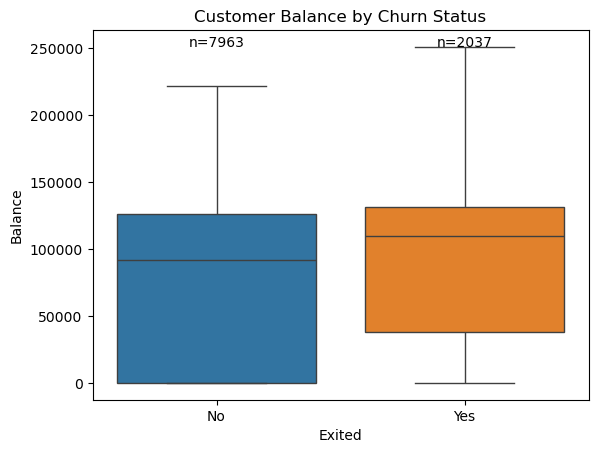

In [20]:
box = sns.boxplot(x='Exited', y='Balance', data=bank_df, hue="Exited")
count = bank_df['Exited'].value_counts()
for i, j in enumerate(count):
    box.text(i, bank_df['Balance'].max(), f'n={j}', ha='center')
plt.title("Customer Balance by Churn Status")
plt.show()

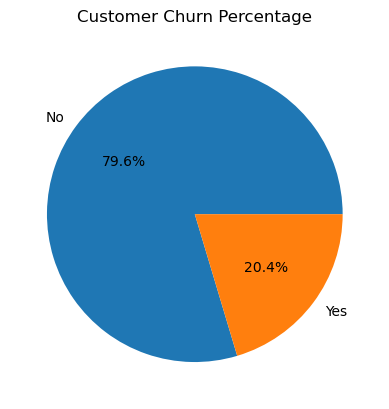

In [21]:
churn_counts = bank_df['Exited'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index.astype(str), autopct='%1.1f%%')
plt.title("Customer Churn Percentage")
plt.show()

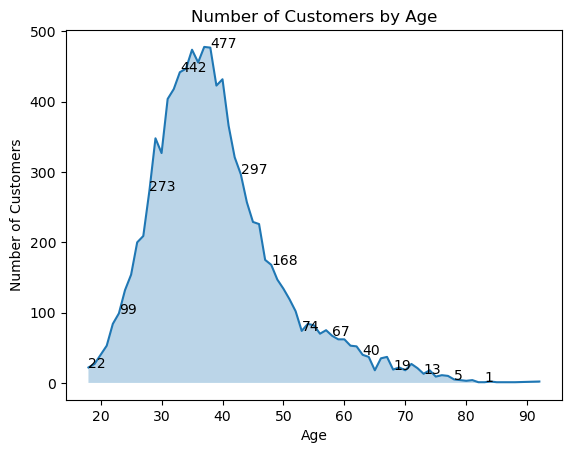

In [23]:
age_counts = bank_df['Age'].value_counts().sort_index()
plt.fill_between(age_counts.index, age_counts.values, alpha=0.3)
plt.plot(age_counts.index, age_counts.values)
for i in range(0, len(age_counts), 5):
    plt.text(age_counts.index[i], age_counts.values[i], age_counts.values[i]) 
plt.title("Number of Customers by Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [25]:
# Remove unwanted column
bank_df = bank_df.drop("Surname", axis=1)

In [36]:
# Convert Text into Numerical values
le = LabelEncoder()

categorical_cols = ["Country", "Gender", "HasCrCard", "IsActiveMember", "Exited"]

for col in categorical_cols:
    bank_df[col] = le.fit_transform(bank_df[col])

In [27]:
# Separate x and y
x = bank_df.drop("Exited", axis=1)  # Independent variables
y = bank_df["Exited"]  # Dependent variables

In [28]:
# Train-Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
# Feature Scaling
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [30]:
# Model (Logistic Regression)
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [38]:
# Prediction
y_pred = model.predict(x_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred),f"({accuracy_score(y_test, y_pred)*100}%)")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8155 (81.55%)

Confusion Matrix:
 [[1559   48]
 [ 321   72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000

